<h1> Imports

In [ ]:
from masterthesis.data.loaders import load_module_dataframe
from masterthesis.data.datasets import subsampled_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot

import numpy as np

<h1> Modular-level Experiments

<h1> Single Cell

<h2> Data

In [2]:
modular_df = load_module_dataframe()

# keep dynamic regimes
#cell_df = cell_df[cell_df["StepIndex"].isin([9, 17,18,19,20,21])]

# downsample

modular_df.head()

,Cell,aged,Resistance,Temp,CurrentA,TestTimes,StepTimes,CycleIndex,StepIndex,VoltageV,TemperatureC_Cell_1,TemperatureC_Cell_2,TemperatureC_Cell_3,TemperatureC_Cell_4,Ambient_TemperatureC,CurrentA_Cell_1,CurrentA_Cell_2,CurrentA_Cell_3,CurrentA_Cell_4
0,Mixed,Aged,0,10,0.0,1.0003,1.0002,1,1,3.572477,19.970938,20.079184,20.310024,20.374929,19.451006,0.345851,-0.278137,0.484834,-0.211766
1,Mixed,Aged,0,10,0.0,2.0003,2.0002,1,1,3.572603,19.970938,20.079184,20.310024,20.374929,19.451006,0.342995,-0.277506,0.487216,-0.201899
2,Mixed,Aged,0,10,0.0,3.0002,3.0001,1,1,3.572414,20.016722,20.002285,20.341354,20.276442,19.561859,0.297878,-0.323768,0.440858,-0.276420
3,Mixed,Aged,0,10,0.0,4.0001,4.0000,1,1,3.571972,19.815464,20.053652,20.234016,20.356627,19.490467,0.298016,-0.326851,0.432864,-0.285413
4,Mixed,Aged,0,10,0.0,5.0003,5.0002,1,1,3.572288,19.790602,20.113615,20.214621,20.438178,19.492714,0.346711,-0.281970,0.489479,-0.207747


<h3> Normalize

In [3]:
groups = [[1, 4, 6], [2, 7], [3, 8], [5]]
cols = ['CurrentA', 'Ambient_TemperatureC', 'VoltageV', 'CycleIndex', 
        'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4',
        'CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3','CurrentA_Cell_4']

env_df = subsampled_env_dict(modular_df, cols, groups, sort_by="StepIndex", max_samples_per_env=20000, seed=42)

Group
0    977525
1    851616
2    324326
3    249502
Name: count, dtype: int64


<h3> Noise

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.000000001,
    seed=42,
)

print(env_data.keys())

dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3)])
after scale: [3.11140003e-14 1.00881501e+00 7.64859570e-01 0.00000000e+00
 1.01091078e+00 1.01199119e+00 1.00985994e+00 1.00900399e+00
 5.24002812e-02 8.12504428e-02 6.13149090e-02 8.46982547e-02]
after noise: [9.98918644e-10 1.00881501e+00 7.64859570e-01 1.00128152e-09
 1.01091078e+00 1.01199119e+00 1.00985994e+00 1.00900399e+00
 5.24002812e-02 8.12504428e-02 6.13149090e-02 8.46982547e-02]
dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3)])


<h3> Dataset

In [5]:
interventions = {
    0: [],     # rest = observational
    1: [0],    # 
    2: [0],    # 
    3: [0],    # 
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)


In [6]:
print(dataset["X"].shape)
print(dataset["X"][:10])
print(dataset["X"].std(axis=0))     


(80000, 12)
[[ 1.52612880e-01 -7.54546897e-02 -7.31386835e-01  1.52302986e-09
  -8.44612323e-02 -1.18880714e-01 -9.96687068e-02 -1.20832706e-01
   1.69278490e-01  1.64052414e-01  1.60549858e-01  1.31482148e-01]
 [ 1.52612880e-01 -5.83801196e-02 -1.78199487e+00 -5.62287529e-10
  -6.06465028e-02 -8.71215257e-02 -6.10503743e-02 -8.81333533e-02
   1.69084571e-01  1.52992208e-01  1.49078367e-01  1.35681723e-01]
 [ 1.52612879e-01 -1.18544291e+00 -7.39382849e-01  3.75698018e-10
  -1.27721342e+00 -1.26231080e+00 -1.25078118e+00 -1.23622248e+00
   1.61017649e-01  1.51788470e-01  1.34743124e-01  1.12413975e-01]
 [ 1.52612880e-01 -1.19827490e+00 -6.74383672e-01  1.96861236e-10
  -1.30470059e+00 -1.29304771e+00 -1.27721030e+00 -1.25897138e+00
   1.70358570e-01  1.60987935e-01  1.39695748e-01  1.41365294e-01]
 [ 1.52612880e-01 -4.71953185e-02 -6.19232233e-01 -3.85082280e-10
  -6.72981994e-02 -9.91947552e-02 -7.96946019e-02 -1.01422654e-01
   1.65402456e-01  1.61762918e-01  1.50086143e-01  1.5131869

In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentA,Ambient_TemperatureC,VoltageV,CycleIndex,TemperatureC_Cell_1,TemperatureC_Cell_2,TemperatureC_Cell_3,TemperatureC_Cell_4,CurrentA_Cell_1,CurrentA_Cell_2,CurrentA_Cell_3,CurrentA_Cell_4
CurrentA,1.000000,-0.033451,0.516977,0.000716,-0.082650,-0.078226,-0.076626,-0.072921,0.986151,0.995009,0.994227,0.990181
Ambient_TemperatureC,-0.033451,1.000000,-0.068507,-0.000027,0.996402,0.996782,0.996994,0.997358,-0.038222,-0.039652,-0.041239,-0.040548
VoltageV,0.516977,-0.068507,1.000000,0.002868,-0.099212,-0.099890,-0.101388,-0.099620,0.457825,0.508735,0.537139,0.556209
CycleIndex,0.000716,-0.000027,0.002868,1.000000,-0.000428,-0.000395,-0.000262,-0.000164,0.000488,0.000868,0.000827,0.000957
TemperatureC_Cell_1,-0.082650,0.996402,-0.099212,-0.000428,1.000000,0.999531,0.999234,0.998843,-0.086222,-0.089511,-0.091919,-0.091335
TemperatureC_Cell_2,-0.078226,0.996782,-0.099890,-0.000395,0.999531,1.000000,0.999564,0.999461,-0.080431,-0.085011,-0.088061,-0.087802
TemperatureC_Cell_3,-0.076626,0.996994,-0.101388,-0.000262,0.999234,0.999564,1.000000,0.999593,-0.077770,-0.082701,-0.086644,-0.086729
TemperatureC_Cell_4,-0.072921,0.997358,-0.099620,-0.000164,0.998843,0.999461,0.999593,1.000000,-0.073866,-0.078540,-0.082572,-0.083335
CurrentA_Cell_1,0.986151,-0.038222,0.457825,0.000488,-0.086222,-0.080431,-0.077770,-0.073866,1.000000,0.989563,0.976958,0.966481
CurrentA_Cell_2,0.995009,-0.039652,0.508735,0.000868,-0.089511,-0.085011,-0.082701,-0.078540,0.989563,1.000000,0.992795,0.986497


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (20000, 12)
1 (20000, 12)
2 (20000, 12)
3 (20000, 12)


In [9]:
print(dataset['envs'])

{np.int64(0): array([[ 0.15261288, -0.07545469, -0.73138684, ...,  0.16405241,
         0.16054986,  0.13148215],
       [ 0.15261288, -0.05838012, -1.78199487, ...,  0.15299221,
         0.14907837,  0.13568172],
       [ 0.15261288, -1.18544291, -0.73938285, ...,  0.15178847,
         0.13474312,  0.11241398],
       ...,
       [ 0.15261288, -1.15184856,  1.08371404, ...,  0.15025934,
         0.17708906,  0.20557178],
       [ 0.15261288,  0.0938607 , -0.75907957, ...,  0.18151399,
         0.18288835,  0.19858816],
       [ 0.15261288, -1.20056215, -1.65265514, ...,  0.1415658 ,
         0.15477854,  0.13419546]]), np.int64(1): array([[ 0.95501144, -0.02239475, -0.02660305, ...,  0.98131441,
         0.93538922,  0.8972402 ],
       [ 0.95502564, -0.00439775, -0.29426304, ...,  0.94577901,
         0.94513056,  0.90308168],
       [ 0.95510161, -1.21028242,  0.07914779, ...,  0.93462192,
         0.9631731 ,  0.88277453],
       ...,
       [ 0.95498623,  1.33144441, -0.22135849, 

<h2> PC

In [10]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/12 [00:00<?, ?it/s]

[[0 0 0 0 1 0 0 0 1 1 1 1]
 [0 0 1 0 0 1 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 0 0 0]
 [0 1 0 0 1 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 1 0 0 0 0]
 [0 1 0 0 0 1 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 1 1 1]
 [1 0 1 0 0 0 0 0 1 0 1 1]
 [1 0 0 0 0 0 0 0 1 1 0 1]
 [1 0 1 0 0 0 0 0 1 1 1 0]]


<h2> No-Tears

In [11]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:03<00:00,  6.24it/s]

[[0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 1 0 0 1 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 1 0 0 0 1 0]
 [0 0 1 0 0 0 0 1 0 0 1 1]
 [0 0 0 0 1 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0]]


<h2> Third alg-Do Tears

In [16]:
dag_dotears = run_dotears(dataset, scaled=True, lambda1=0.05)
print(dag_dotears)

0 h = 0.8256701945362472
1 h = 0.15507505296720758
2 h = 0.019590526093008265
3 h = 0.002858183210999954
4 h = 0.0003406125374691982
[[0 1 1 0 1 0 1 0 1 1 1 1]
 [0 0 1 0 0 1 0 0 1 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 0 1 0 1 0]
 [0 0 1 0 1 0 0 0 1 1 0 1]
 [0 0 1 0 0 0 0 1 1 0 1 1]
 [0 1 1 0 0 0 0 0 1 1 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0]]


<h2> Compare/Results?

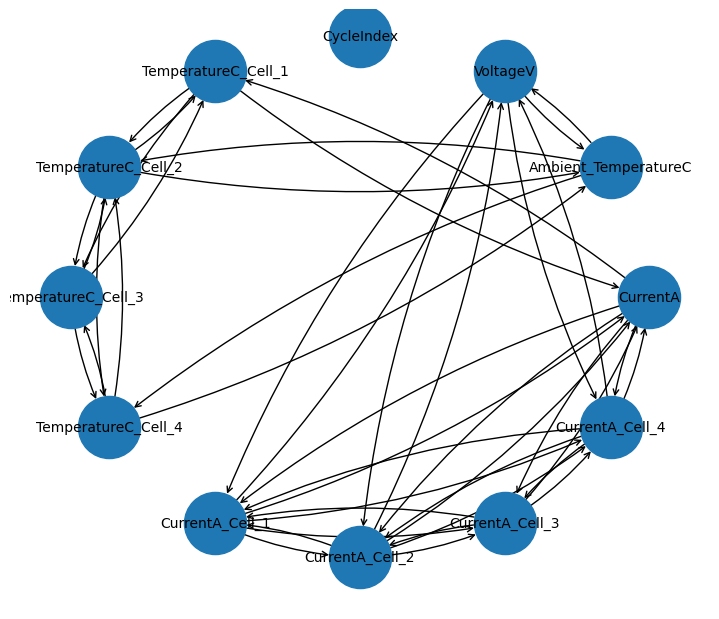

In [13]:
save_graph_plot(cols, dag_pc) 

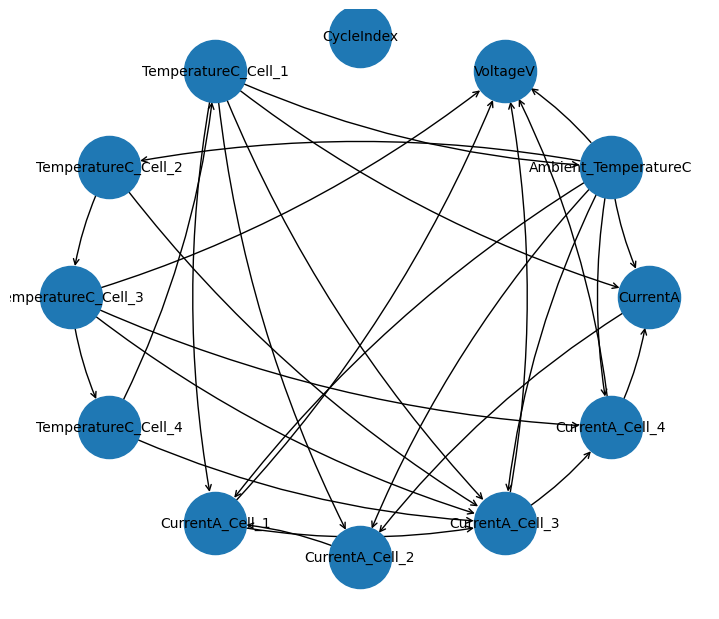

In [14]:
save_graph_plot(cols, dag_notears) 

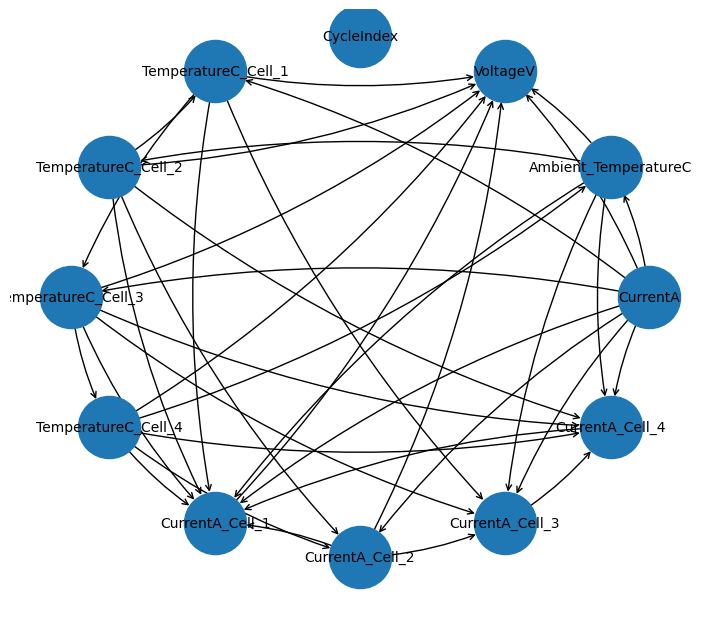

In [17]:
save_graph_plot(cols, dag_dotears) 